Rows in catalogue: 1701
Supernovae used in the analysis: 1466
Best-fit matter density:      0.2986
Best-fit dark-energy density: 0.5706
Deceleration parameter q0:    -0.4214  (negative = accelerating)

Model                      chi2   chi2/dof
Best fit                  638.8      0.437
Flat LambdaCDM            647.0      0.442
Empty universe            669.6      0.458
Matter only (EdS)        1227.8      0.839

H0 from z < 0.1: 69.271 km/s/Mpc


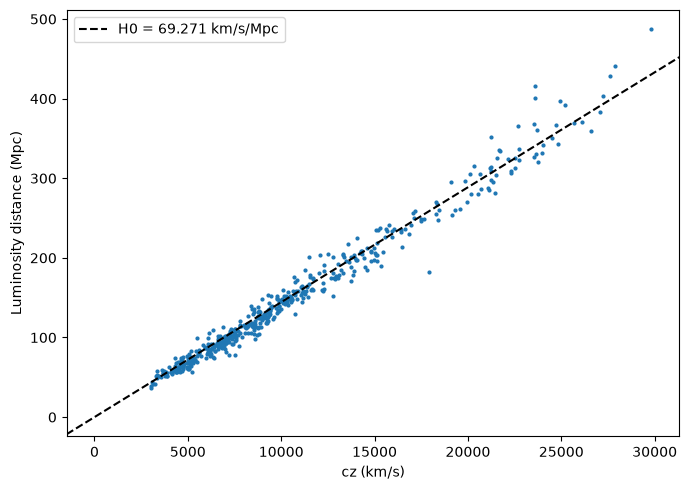

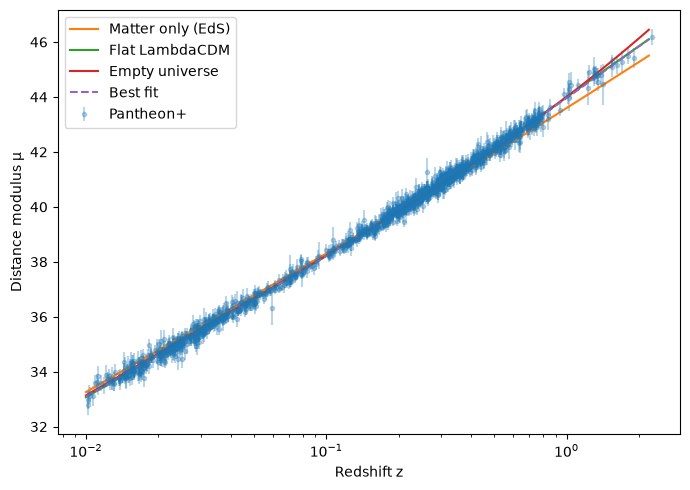

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import minimize

DATA_FILE = "Pantheon+SH0ES.dat"

SPEED_OF_LIGHT_KM_S = 299792.458
REFERENCE_HUBBLE_CONSTANT = 70.0       # km/s/Mpc

MIN_REDSHIFT = 0.01                    
LOW_REDSHIFT_LIMIT = 0.1             

REMOVE_CALIBRATORS = True             
REMOVE_DUPLICATES = True               

catalogue = pd.read_csv(DATA_FILE, sep=r"\s+")
print("Rows in catalogue:", len(catalogue))

keep_row = (catalogue.zHD > MIN_REDSHIFT) & (catalogue.MU_SH0ES_ERR_DIAG > 0)

if REMOVE_CALIBRATORS:
    keep_row = keep_row & (catalogue.IS_CALIBRATOR == 0)

catalogue = catalogue[keep_row]

if REMOVE_DUPLICATES:
    catalogue = catalogue.sort_values("MU_SH0ES_ERR_DIAG").drop_duplicates("CID")

redshift = catalogue.zHD.values
distance_modulus = catalogue.MU_SH0ES.values
distance_modulus_error = catalogue.MU_SH0ES_ERR_DIAG.values
fit_weights = 1.0 / distance_modulus_error**2

print("Supernovae used in the analysis:", len(redshift))

def luminosity_distance(redshifts, matter_density, dark_energy_density,
                        hubble_constant=REFERENCE_HUBBLE_CONSTANT):
    curvature_density = 1 - matter_density - dark_energy_density

    def expansion_rate_ratio(z_value):
        return np.sqrt(matter_density * (1 + z_value)**3
                       + curvature_density * (1 + z_value)**2
                       + dark_energy_density)

    hubble_distance = SPEED_OF_LIGHT_KM_S / hubble_constant

    #Comoving distance = integral of c / H(z) from 0 to z
    comoving_distance = hubble_distance * np.array([
        quad(lambda z_value: 1 / expansion_rate_ratio(z_value), 0, z_end)[0]
        for z_end in np.atleast_1d(redshifts)
    ])

    curvature_scale = np.sqrt(abs(curvature_density))
    scaled_distance = comoving_distance / hubble_distance

    if curvature_density > 1e-8:        # open universe
        transverse_distance = hubble_distance * np.sinh(curvature_scale * scaled_distance) / curvature_scale
    elif curvature_density < -1e-8:     # closed universe
        transverse_distance = hubble_distance * np.sin(curvature_scale * scaled_distance) / curvature_scale
    else:                               # flat universe
        transverse_distance = comoving_distance

    return (1 + redshifts) * transverse_distance


def model_distance_modulus(redshifts, matter_density, dark_energy_density):
    distance = luminosity_distance(redshifts, matter_density, dark_energy_density)
    return 5 * np.log10(distance) + 25


def best_offset(matter_density, dark_energy_density):
    residuals = distance_modulus - model_distance_modulus(redshift, matter_density, dark_energy_density)
    return np.average(residuals, weights=fit_weights)


def model_with_offset(redshift_grid, matter_density, dark_energy_density):
    return (model_distance_modulus(redshift_grid, matter_density, dark_energy_density)
            + best_offset(matter_density, dark_energy_density))


def chi_squared(matter_density, dark_energy_density):
    residuals = distance_modulus - model_distance_modulus(redshift, matter_density, dark_energy_density)
    offset = np.average(residuals, weights=fit_weights)
    return np.sum(fit_weights * (residuals - offset)**2)


def chi_squared_for_optimizer(parameters):
    matter_density, dark_energy_density = parameters
    return chi_squared(matter_density, dark_energy_density)


fit_result = minimize(chi_squared_for_optimizer, x0=[0.3, 0.7], method="Nelder-Mead")
best_matter_density, best_dark_energy_density = fit_result.x
deceleration_parameter = best_matter_density / 2 - best_dark_energy_density

print(f"Best-fit matter density:      {best_matter_density:.4f}")
print(f"Best-fit dark-energy density: {best_dark_energy_density:.4f}")
print(f"Deceleration parameter q0:    {deceleration_parameter:.4f}  (negative = accelerating)")

reference_models = {
    "Best fit":          (best_matter_density, best_dark_energy_density),
    "Flat LambdaCDM":    (0.3, 0.7),
    "Empty universe":    (0.0, 0.0),
    "Matter only (EdS)": (1.0, 0.0),
}

number_of_points = len(redshift)
print(f"\n{'Model':20s} {'chi2':>10s} {'chi2/dof':>10s}")
for model_name, (matter_density, dark_energy_density) in reference_models.items():
    chi2_value = chi_squared(matter_density, dark_energy_density)
    print(f"{model_name:20s} {chi2_value:10.1f} {chi2_value / (number_of_points - 3):10.3f}")

# Plot 1: low-redshift Hubble law
is_low_redshift = redshift < LOW_REDSHIFT_LIMIT
low_redshift_velocity = SPEED_OF_LIGHT_KM_S * redshift[is_low_redshift]          # cz in km/s
low_redshift_distance = 10 ** ((distance_modulus[is_low_redshift] - 25) / 5)     # Mpc

hubble_constant_estimate = (np.sum(low_redshift_velocity * low_redshift_distance)
                            / np.sum(low_redshift_distance**2))
print(f"\nH0 from z < {LOW_REDSHIFT_LIMIT}: {hubble_constant_estimate:.3f} km/s/Mpc")

plt.figure(figsize=(7, 5))
plt.scatter(low_redshift_velocity, low_redshift_distance, s=4)
plt.axline((0, 0), slope=1 / hubble_constant_estimate, color="black", linestyle="--",
           label=f"H0 = {hubble_constant_estimate:.3f} km/s/Mpc")
plt.xlabel("cz (km/s)")
plt.ylabel("Luminosity distance (Mpc)")
plt.legend()
plt.tight_layout()
plt.savefig("hubble law for low z.png", dpi=200)

# Plot 2: Hubble diagram
redshift_grid = np.linspace(0.01, 2.2, 80)

plot_models = [
    (1.0, 0.0, "Matter only (EdS)", "-"),
    (0.3, 0.7, "Flat LambdaCDM", "-"),
    (0.0, 0.0, "Empty universe", "-"),
    (best_matter_density, best_dark_energy_density, "Best fit", "--"),
]

plt.figure(figsize=(7, 5))
plt.errorbar(redshift, distance_modulus, distance_modulus_error, fmt=".", alpha=0.3, label="Pantheon+")
for matter_density, dark_energy_density, label, line_style in plot_models:
    plt.plot(redshift_grid,
             model_with_offset(redshift_grid, matter_density, dark_energy_density),
             line_style, label=label)

plt.xscale("log")
plt.xlabel("Redshift z")
plt.ylabel("Distance modulus μ")
plt.legend()
plt.tight_layout()
plt.savefig("hubble_diagram.png", dpi=200)



plt.show()